In [2]:
import sys
import os

# Add the parent directory to Python's search path
sys.path.append(os.path.abspath('..'))

🎨 Generating QR codes for the gallery...


C:\Users\rajpa\AppData\Local\Temp\ipykernel_23196\860708493.py:73: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.93])
C:\Users\rajpa\AppData\Local\Temp\ipykernel_23196\860708493.py:73: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.93])
C:\Users\rajpa\AppData\Local\Temp\ipykernel_23196\860708493.py:75: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.savefig(gallery_path, dpi=300, bbox_inches='tight')
C:\Users\rajpa\AppData\Local\Temp\ipykernel_23196\860708493.py:75: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) DejaVu Sans.
  plt.savefig(gallery_path, dpi=300, bbox_inches='tight')
e:\Quantum Computing\Projects\quantum-tamper-evident-qr\.quantum-tamper-evident\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

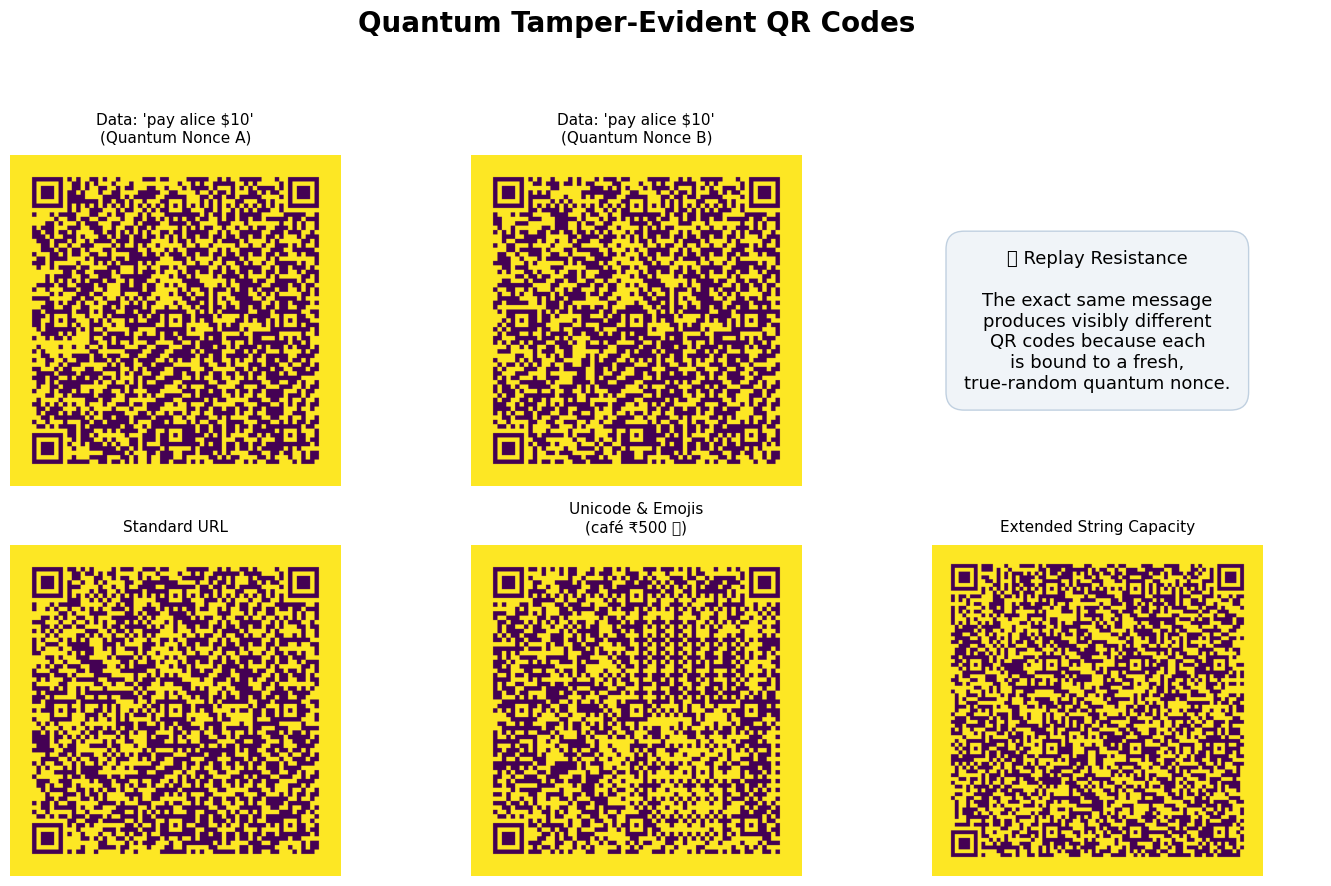

✅ Success! Gallery saved to ../data/gallery.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from quantum_qr import generate

# Ensure the output directory exists
out_dir = "../data"
os.makedirs(out_dir, exist_ok=True)

print("🎨 Generating QR codes for the gallery...")

# ---------------------------------------------------------
# 1. Generate the QRs
# ---------------------------------------------------------

# Row 1: The Replay Resistance Demo (Same data, different nonces)
qr1 = generate("pay alice $10", f"{out_dir}/temp_r1_1.png")
qr2 = generate("pay alice $10", f"{out_dir}/temp_r1_2.png")

# Row 2: Payload Variety
qr3 = generate("https://github.com", f"{out_dir}/temp_r2_1.png")
qr4 = generate("café ₹500 🤝", f"{out_dir}/temp_r2_2.png")
long_text = "This is a significantly longer string to demonstrate that the payload can safely expand and still be encoded seamlessly."
qr5 = generate(long_text, f"{out_dir}/temp_r2_3.png")

# ---------------------------------------------------------
# 2. Build the Gallery with Matplotlib
# ---------------------------------------------------------

# Create a figure with 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.patch.set_facecolor('white')  # Ensure a clean white background

# Hide all axes right away (we only want the images and titles)
for ax in axes.flat:
    ax.axis('off')

# --- Row 1: Replay Resistance ---
axes[0, 0].imshow(mpimg.imread(qr1["output_path"]))
axes[0, 0].set_title("Data: 'pay alice $10'\n(Quantum Nonce A)", fontsize=11, pad=10)

axes[0, 1].imshow(mpimg.imread(qr2["output_path"]))
axes[0, 1].set_title("Data: 'pay alice $10'\n(Quantum Nonce B)", fontsize=11, pad=10)

# Add an explanatory text box in the empty top-right slot
axes[0, 2].text(
    0.5, 0.5, 
    "🛡️ Replay Resistance\n\nThe exact same message\nproduces visibly different\nQR codes because each\nis bound to a fresh,\ntrue-random quantum nonce.", 
    fontsize=13, 
    ha='center', 
    va='center',
    bbox=dict(boxstyle="round,pad=1", facecolor="#f0f4f8", edgecolor="#c0d0e0")
)

# --- Row 2: Variety ---
axes[1, 0].imshow(mpimg.imread(qr3["output_path"]))
axes[1, 0].set_title("Standard URL", fontsize=11, pad=10)

axes[1, 1].imshow(mpimg.imread(qr4["output_path"]))
axes[1, 1].set_title("Unicode & Emojis\n(café ₹500 🤝)", fontsize=11, pad=10)

axes[1, 2].imshow(mpimg.imread(qr5["output_path"]))
axes[1, 2].set_title("Extended String Capacity", fontsize=11, pad=10)

# Main Title
fig.suptitle(
    "Quantum Tamper-Evident QR Codes", 
    fontsize=20, 
    fontweight='bold', 
    y=0.98
)

# Adjust layout and save
plt.tight_layout(rect=[0, 0, 1, 0.93])
gallery_path = f"{out_dir}/gallery.png"
plt.savefig(gallery_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Success! Gallery saved to {gallery_path}")

# Optional: Clean up the temporary individual images
for temp_file in [qr1, qr2, qr3, qr4, qr5]:
    os.remove(temp_file["output_path"])